# Linear regression models to study UDG repair enzyme mechanism

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from itertools import combinations
import logomaker
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import Lasso, LassoCV
from statsmodels.stats.multitest import multipletests
import os

In [3]:
# load data:
df = pd.read_csv('data/UDG_binding_NNUNNN_UG_processed_normalized.csv') 
df

,Flanks,ln_FI_normalized
0,AAUAAA,10.684182
1,AAUAAC,10.305242
2,AAUAAG,10.213125
3,AAUAAT,10.515740
4,AAUACA,9.861040
...,...,...
1019,TTUTGT,8.829071
1020,TTUTTA,9.670830
1021,TTUTTC,9.390866
1022,TTUTTG,9.661965


### Simpler linear regression - additivity

In [5]:
# one hot encoding:
context_columns = ['pos_' + str(i) for i in (-2,-1,0,1,2,3)]
df[context_columns] = df['Flanks'].apply(lambda x: pd.Series(list(x)))
df

,Flanks,ln_FI_normalized,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3
0,AAUAAA,10.684182,A,A,U,A,A,A
1,AAUAAC,10.305242,A,A,U,A,A,C
2,AAUAAG,10.213125,A,A,U,A,A,G
3,AAUAAT,10.515740,A,A,U,A,A,T
4,AAUACA,9.861040,A,A,U,A,C,A
...,...,...,...,...,...,...,...,...
1019,TTUTGT,8.829071,T,T,U,T,G,T
1020,TTUTTA,9.670830,T,T,U,T,T,A
1021,TTUTTC,9.390866,T,T,U,T,T,C
1022,TTUTTG,9.661965,T,T,U,T,T,G


In [6]:
# Define nucleotides
bases = ['A', 'C', 'G', 'T']
base_to_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
# Make sure ACGT indexing
base_to_index

{'A': 0, 'C': 1, 'G': 2, 'T': 3}

In [7]:
# One hot encoding flanks:
def one_hot_encode_flanks(row):
    positions = [row['pos_-2'], row['pos_-1'], row['pos_1'], row['pos_2'], row['pos_3']]
    encoding = np.zeros((5, 4))  # 5 positions x 4 bases
    for i, base in enumerate(positions):
        if base in base_to_index:  # skip lesion in pos 0
            encoding[i, base_to_index[base]] = 1
    return encoding.flatten()

In [8]:
df['one_hot'] = df.apply(one_hot_encode_flanks, axis=1)
df

,Flanks,ln_FI_normalized,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot
0,AAUAAA,10.684182,A,A,U,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
1,AAUAAC,10.305242,A,A,U,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
2,AAUAAG,10.213125,A,A,U,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
3,AAUAAT,10.515740,A,A,U,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
4,AAUACA,9.861040,A,A,U,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
...,...,...,...,...,...,...,...,...,...
1019,TTUTGT,8.829071,T,T,U,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1020,TTUTTA,9.670830,T,T,U,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1021,TTUTTC,9.390866,T,T,U,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1022,TTUTTG,9.661965,T,T,U,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


### train-test split

In [ ]:
X = np.vstack(df['one_hot'].values)  
y = df['ln_FI_normalized'].values  

# define x, y train and test:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape

In [ ]:
reg = LinearRegression().fit(X_train, y_train)

# Predictions on test set
y_pred = reg.predict(X_test)

# Metrics
r2_train = reg.score(X_train, y_train)           # R^2 on train
r2_test  = reg.score(X_test, y_test)             # R^2 on test
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

print(f"R^2 (train): {r2_train:.3f}")
print(f"R^2 (test):  {r2_test:.3f}")
print(f"RMSE (test): {rmse_test:.4f}")
print("Coefficients shape:", reg.coef_.shape)

R^2 (train): 0.704
R^2 (test):  0.783
RMSE (test): 0.3211
Coefficients shape: (20,)


In [ ]:
reg.coef_, reg.intercept_

array([ 0.08079769, -0.08274482,  0.0698192 , -0.06787208,  0.16639704,
       -0.6246181 ,  0.32074476,  0.13747629,  0.69142068, -0.25162271,
       -0.06514926, -0.37464872, -0.00625935, -0.25880197, -0.16919012,
        0.43425144,  0.06150579, -0.11208335, -0.0255337 ,  0.07611126])

In [19]:
# Predictions on full data
y_pred = reg.predict(X_test)

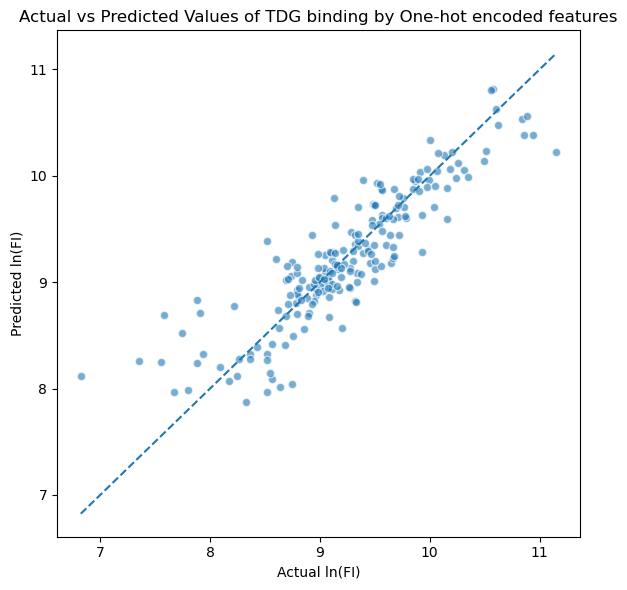

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='w')
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel("Actual ln(FI)")
plt.ylabel("Predicted ln(FI)")
plt.title("Actual vs Predicted Values of TDG binding by One-hot encoded features")
plt.tight_layout()
plt.show()

### Create PWM logo

In [ ]:
# reshape mono coefficients: 24 -> (6 positions, 4 bases)
coef_matrix = reg.coef_.reshape(5, 4)   # assumes one-hot flattened as [A,C,G,T] per position

# integer positions for the x-axis
pos_int   = [-2, -1, 1, 2, 3]
bases     = ['A','C','G','T']

df_logo = pd.DataFrame(coef_matrix, columns=bases, index=pos_int)
df_logo

,A,C,G,T
-2,0.080798,-0.082745,0.069819,-0.067872
-1,0.166397,-0.624618,0.320745,0.137476
1,0.691421,-0.251623,-0.065149,-0.374649
2,-0.006259,-0.258802,-0.169190,0.434251
3,0.061506,-0.112083,-0.025534,0.076111


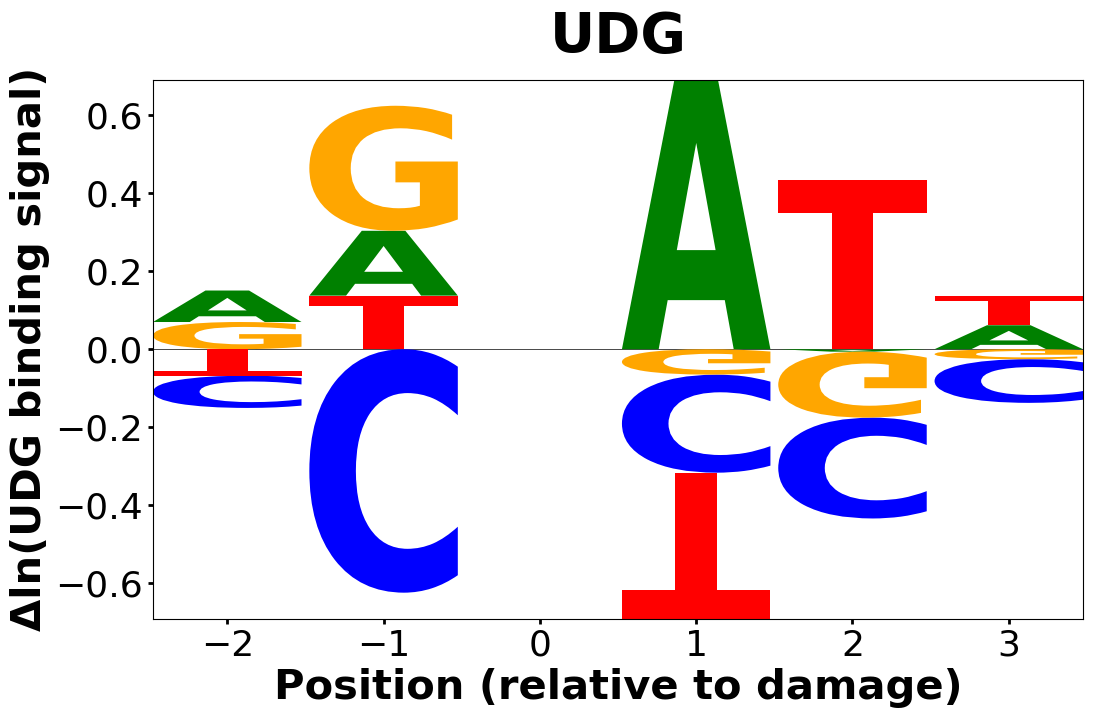

In [ ]:
# Make PWM figure
fig, ax = plt.subplots(figsize=(12, 7))

logomaker.Logo(df_logo,ax=ax,shade_below=0.0,  fade_below=0.0, center_values=True)  

# Customize labels, ticks, title
ax.set_ylabel('Δln(UDG binding signal)', fontsize=30, fontweight='bold')
ax.set_xlabel('Position (relative to damage)', fontsize=30, fontweight='bold')
ax.set_title('UDG', fontsize=40, fontweight='bold', pad=20)

# Tick sizes
ax.tick_params(axis='x', labelsize=26, width=2)
ax.tick_params(axis='y', labelsize=26, width=2)

In [ ]:
# show coefficiants as a heatmap
coef_df_scaled = coef_df 
plt.figure(figsize=(6, 4))
sns.heatmap(coef_df_scaled, annot=True, fmt=".2f", cmap="vlag", center=0,
            linewidths=0.5, cbar_kws={'label': 'Coefficient (×1e13)'})
plt.title("TDG Model Coefficients per Base and Position", fontsize=13)
plt.xlabel("Base", fontsize=12)
plt.ylabel("Position", fontsize=12)
plt.tight_layout()
plt.show()

## linear regression with dependencies between adjacent positions

In [22]:
df

,Flanks,ln_FI_normalized,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot
0,AAUAAA,10.684182,A,A,U,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
1,AAUAAC,10.305242,A,A,U,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
2,AAUAAG,10.213125,A,A,U,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
3,AAUAAT,10.515740,A,A,U,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
4,AAUACA,9.861040,A,A,U,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
...,...,...,...,...,...,...,...,...,...
1019,TTUTGT,8.829071,T,T,U,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1020,TTUTTA,9.670830,T,T,U,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1021,TTUTTC,9.390866,T,T,U,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1022,TTUTTG,9.661965,T,T,U,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


In [23]:
# Define columns and create dinucleotide features 
mono_cols = ['pos_-2','pos_-1','pos_1','pos_2','pos_3']

# Adjacent pairs:
df = df.copy()
df['di_-2_-1'] = df['pos_-2'] + df['pos_-1']
df['di_1_2']   = df['pos_1']  + df['pos_2']
df['di_2_3']   = df['pos_2']  + df['pos_3']

# include cross-lesion interaction (-1, +1) 
df['di_-1_1'] = df['pos_-1'] + df['pos_1']

di_cols = ['di_-2_-1','di_1_2','di_2_3', 'di_-1_1']
df

,Flanks,ln_FI_normalized,pos_-2,pos_-1,pos_0,pos_1,pos_2,pos_3,one_hot,di_-2_-1,di_1_2,di_2_3,di_-1_1
0,AAUAAA,10.684182,A,A,U,A,A,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AA,AA
1,AAUAAC,10.305242,A,A,U,A,A,C,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AC,AA
2,AAUAAG,10.213125,A,A,U,A,A,G,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AG,AA
3,AAUAAT,10.515740,A,A,U,A,A,T,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AA,AT,AA
4,AAUACA,9.861040,A,A,U,A,C,A,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...",AA,AC,CA,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,TTUTGT,8.829071,T,T,U,T,G,T,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TG,GT,TT
1020,TTUTTA,9.670830,T,T,U,T,T,A,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TA,TT
1021,TTUTTC,9.390866,T,T,U,T,T,C,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TC,TT
1022,TTUTTG,9.661965,T,T,U,T,T,G,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",TT,TT,TG,TT


In [24]:
#  One-hot encoders for mono and di features 
bases = ['A','C','G','T']
dinucs = [a+b for a in bases for b in bases]  # 16 ordered combos: AA, AC, ..., TT

mono_encoder = OneHotEncoder(categories=[bases]*len(mono_cols),
                             handle_unknown='ignore', sparse_output=False)
di_encoder   = OneHotEncoder(categories=[dinucs]*len(di_cols),
                             handle_unknown='ignore', sparse_output=False)

# ColumnTransformer to combine both sets 
ct = ColumnTransformer(
    transformers=[
        ('mono', mono_encoder, mono_cols),
        ('di',   di_encoder,   di_cols),
    ],
    remainder='drop'
)

### CV for a hint on alpha's range + inspect closely to pick the best tradeoff between # of features and R squared

In [25]:
X = df[mono_cols + di_cols]
y = df['ln_FI_normalized'].values

# 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [ ]:
X_train.shape, X_val.shape, y_test.shape

In [26]:
alpha_grid = np.logspace(-4, -1, 30)  
lasso_cv_model = make_pipeline(
    ct,
    LassoCV(alphas=alpha_grid, cv=5, max_iter=100000, random_state=42)
)
lasso_cv_model.fit(X_train, y_train)

# Extract best alpha
lasso_cv = lasso_cv_model.named_steps['lassocv']
best_alpha = lasso_cv.alpha_

print(f"Best alpha from CV: {best_alpha:.5g}")
print(f"R² (Train): {lasso_cv_model.score(X_train, y_train):.4f}")
print(f"# non-zero features: {np.sum(lasso_cv.coef_ != 0)}")

Best alpha from CV: 0.0013738
R² (Train): 0.7771
# non-zero features: 47


In [27]:
manual_alphas = sorted(set([
    best_alpha * f for f in [1, 1.5, 2, 5, 10,20,30,50]
]))

manual_results = []
for alpha in manual_alphas:
    model = make_pipeline(ct, Lasso(alpha=alpha, max_iter=100000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    manual_results.append({
        'alpha': alpha,
        'train_R2': model.score(X_train, y_train),
        'val_R2': r2_score(y_val, y_pred),
        #'RMSE': mean_squared_error(y_val, y_pred, squared=False),
        'n_features': np.sum(model.named_steps['lasso'].coef_ != 0)
    })

manual_df = pd.DataFrame(manual_results)
manual_df

,alpha,train_R2,val_R2,n_features
0,0.001374,0.777115,0.829829,47
1,0.002061,0.774617,0.831843,41
2,0.002748,0.771637,0.832467,40
3,0.006869,0.742563,0.813339,31
4,0.013738,0.686536,0.761792,20
5,0.027476,0.623157,0.692689,7
6,0.041215,0.584190,0.646712,6
7,0.068691,0.493776,0.531102,3


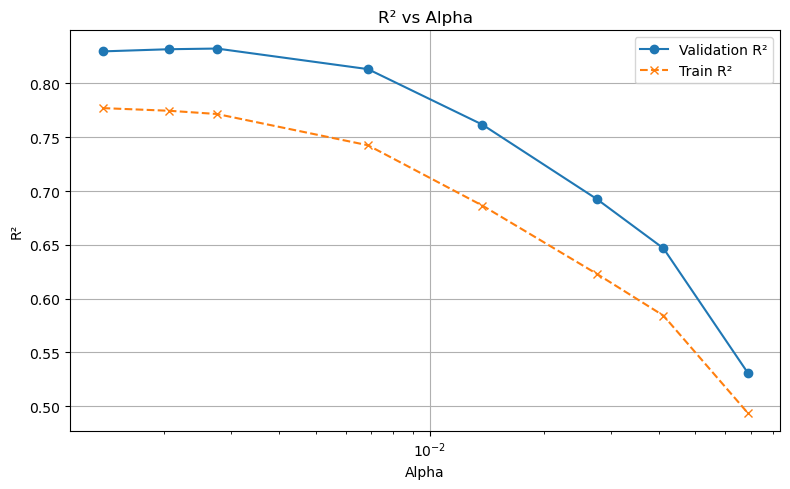

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(manual_df['alpha'], manual_df['val_R2'], 'o-', label='Validation R²')
plt.plot(manual_df['alpha'], manual_df['train_R2'], 'x--', label='Train R²')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("R² vs Alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

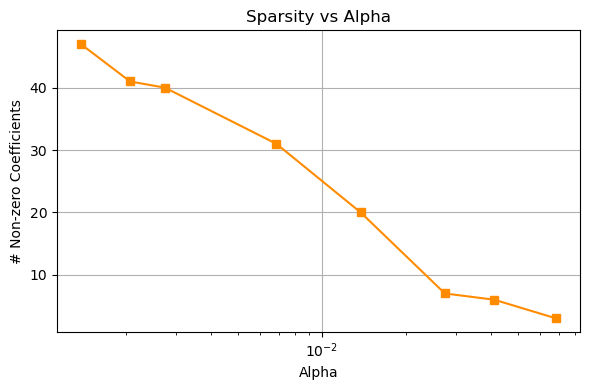

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(manual_df['alpha'], manual_df['n_features'], 's-', color='darkorange')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("# Non-zero Coefficients")
plt.title("Sparsity vs Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
tolerance = 0.005
max_val_r2 = manual_df['val_R2'].max()
within_tolerance = manual_df[manual_df['val_R2'] >= (max_val_r2 - tolerance)]
sweet_spot = within_tolerance.sort_values(by='n_features').iloc[0]

print(f" Sweet spot alpha: {sweet_spot['alpha']:.5g}")
print(f"    → Val R²: {sweet_spot['val_R2']:.4f}")
print(f"    → Non-zero features: {int(sweet_spot['n_features'])}")

best_alpha = sweet_spot['alpha']

 Sweet spot alpha: 0.0027476
    → Val R²: 0.8325
    → Non-zero features: 40


In [ ]:
final_model = make_pipeline(ct, Lasso(alpha=best_alpha, max_iter=100000))
final_model.fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

print(f" Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f" Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

 Test R²: 0.8296


In [29]:
coef_array = final_model.named_steps['lasso'].coef_
feature_names = ct.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_array
}).sort_values("Coefficient", ascending=False)

# Report number of coefficients
n_total = len(coef_array)
n_nonzero = np.sum(coef_array != 0)
print(f" Total features: {n_total}")
print(f" Non-zero (selected) features: {n_nonzero}")
print(f" Zeroed-out features: {n_total - n_nonzero}")

 Total features: 84
 Non-zero (selected) features: 40
 Zeroed-out features: 44


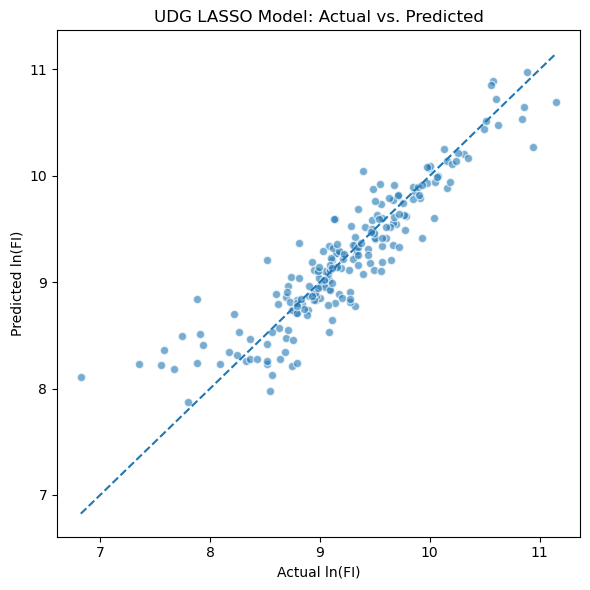

In [30]:
# Plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w')
lo, hi = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel("Actual ln(FI)")
plt.ylabel("Predicted ln(FI)")
plt.title("UDG LASSO Model: Actual vs. Predicted")
plt.tight_layout()
plt.show()

In [31]:
# Show top coefficients
feature_names = final_model.named_steps['columntransformer'].get_feature_names_out()
coefs = final_model.named_steps['lasso'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
nz = coef_df[coef_df['coef'] != 0].copy()
nz['abs'] = nz['coef'].abs()
nz = nz.sort_values(by='abs', ascending=False)
print(f"Top features:\n")
display(nz.head(15))

Top features:



,feature,coef,abs
5,mono__pos_-1_C,-0.714940,0.714940
8,mono__pos_1_A,0.646516,0.646516
15,mono__pos_2_T,0.428488,0.428488
76,di__di_-1_1_GA,0.368216,0.368216
36,di__di_1_2_AA,0.356829,0.356829
41,di__di_1_2_CC,-0.333578,0.333578
20,di__di_-2_-1_AA,0.280664,0.280664
81,di__di_-1_1_TC,0.240590,0.240590
83,di__di_-1_1_TT,-0.218293,0.218293
32,di__di_-2_-1_TA,-0.216608,0.216608
